# Feature Importance & SHAP Analysis

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('/kaggle/input/heart-failure-clinical-data/heart_failure_clinical_records_dataset.csv')
X = df.drop(['DEATH_EVENT', 'time'], axis=1) # Dropping time to avoid data leakage
y = df['DEATH_EVENT']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Training the Model

In [2]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=50, max_depth=None, min_samples_split=10, random_state=42)
model.fit(X_train, y_train)

print("Model trained.")

Model trained.


## SHAP Analysis

In [3]:
import shap

# Create tree explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# In binary classification, shap_values is a list of two arrays (for class 0 and 1).
# We focus on class 1 (Death Event).
shap_values_death = shap_values[1]

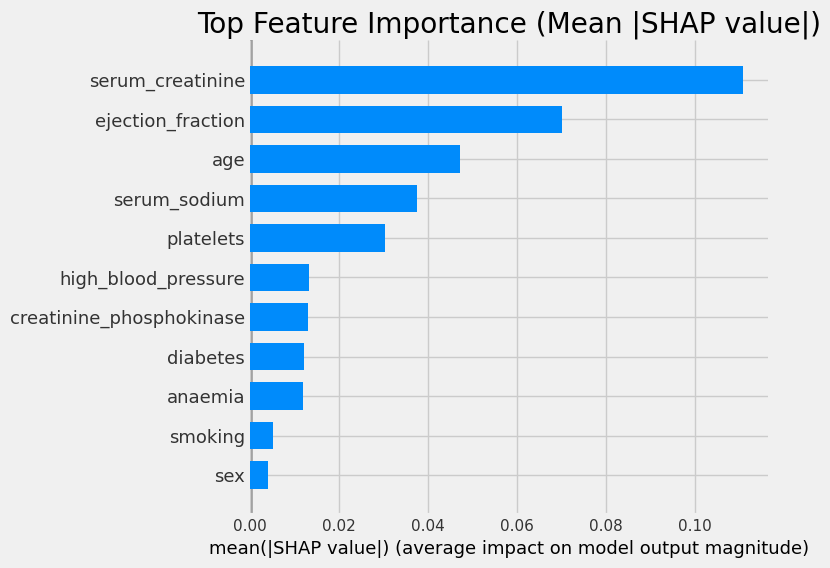

In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

# --- PLOT 1: Feature Importance (Bar Plot) ---
plt.figure(figsize=(10, 6))
plt.title("Top Feature Importance (Mean |SHAP value|)")
shap.summary_plot(shap_values_death, X_test, plot_type="bar", show=False)
plt.show()

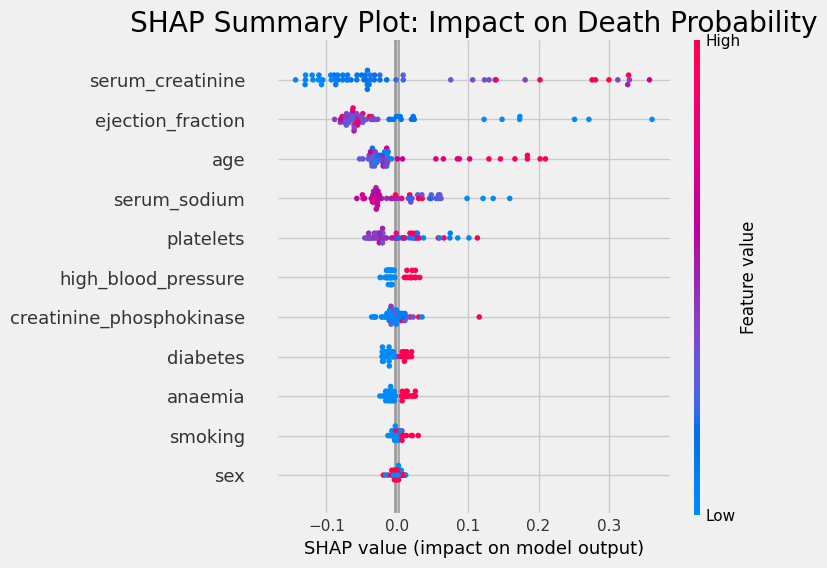

In [5]:
# --- PLOT 2: Summary Plot (Beeswarm) ---
plt.figure(figsize=(12, 8))
plt.title("SHAP Summary Plot: Impact on Death Probability")
shap.summary_plot(shap_values_death, X_test, show=False)
plt.show()

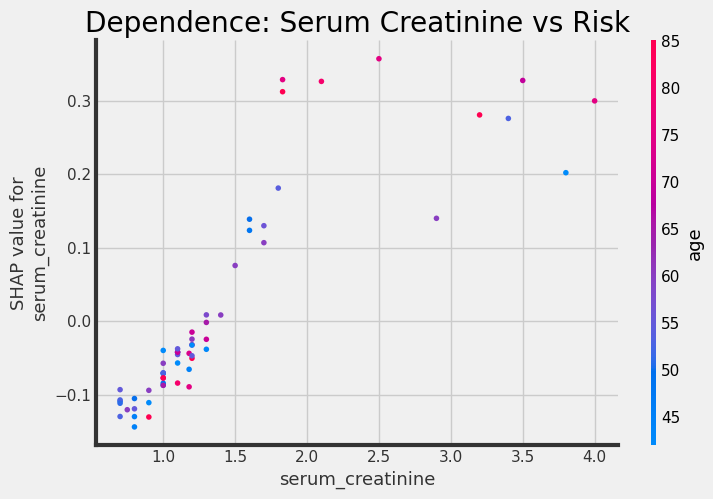

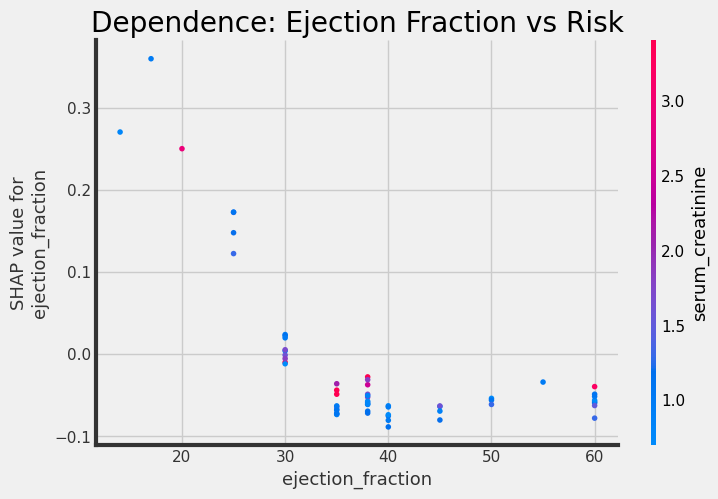

In [6]:
# --- PLOT 3: Dependence Plot (Serum Creatinine) ---
# Shows how risk changes with serum creatinine levels
shap.dependence_plot("serum_creatinine", shap_values_death, X_test, interaction_index="age", show=False)
plt.title("Dependence: Serum Creatinine vs Risk")
plt.show()

# --- PLOT 4: Dependence Plot (Ejection Fraction) ---
shap.dependence_plot("ejection_fraction", shap_values_death, X_test, interaction_index="serum_creatinine", show=False)
plt.title("Dependence: Ejection Fraction vs Risk")
plt.show()

In [7]:
# --- PLOT 5: Individual Force Plot (Local Explanation) ---
# Analyzing the first patient in the test set
shap.initjs() # Required for JS plots
print("Force Plot for the first patient in test set:")
display(shap.force_plot(explainer.expected_value[1], shap_values_death[0,:], X_test.iloc[0,:]))

Force Plot for the first patient in test set:
